In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


In [22]:
class AutoencoderNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1, 3, 32, 32)

In [23]:
class AutoencoderCNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [32]:
def train_model(model, epochs=10, l1_lambda=0.0, weight_decay=0.0):

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)

    for epoch in range(epochs):
        total_loss = 0

        for images, _ in train_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}  Loss: {total_loss/len(train_loader):.4f}")

    return model

In [33]:
# NN Base
nn_base = train_model(AutoencoderNN())

# NN + L1
nn_l1 = train_model(AutoencoderNN(), l1_lambda=1e-6)

# NN + L2
nn_l2 = train_model(AutoencoderNN(), weight_decay=1e-5)

# NN + Dropout
nn_dropout = train_model(AutoencoderNN(dropout_rate=0.3))

Epoch 1/10  Loss: 0.0276
Epoch 2/10  Loss: 0.0163
Epoch 3/10  Loss: 0.0145
Epoch 4/10  Loss: 0.0138
Epoch 5/10  Loss: 0.0135
Epoch 6/10  Loss: 0.0132
Epoch 7/10  Loss: 0.0130
Epoch 8/10  Loss: 0.0129
Epoch 9/10  Loss: 0.0127
Epoch 10/10  Loss: 0.0127
Epoch 1/10  Loss: 0.0484
Epoch 2/10  Loss: 0.0351
Epoch 3/10  Loss: 0.0301
Epoch 4/10  Loss: 0.0279
Epoch 5/10  Loss: 0.0268
Epoch 6/10  Loss: 0.0268
Epoch 7/10  Loss: 0.0271
Epoch 8/10  Loss: 0.0247
Epoch 9/10  Loss: 0.0225
Epoch 10/10  Loss: 0.0219
Epoch 1/10  Loss: 0.0306
Epoch 2/10  Loss: 0.0194
Epoch 3/10  Loss: 0.0174
Epoch 4/10  Loss: 0.0164
Epoch 5/10  Loss: 0.0155
Epoch 6/10  Loss: 0.0156
Epoch 7/10  Loss: 0.0148
Epoch 8/10  Loss: 0.0148
Epoch 9/10  Loss: 0.0143
Epoch 10/10  Loss: 0.0149
Epoch 1/10  Loss: 0.0326
Epoch 2/10  Loss: 0.0239
Epoch 3/10  Loss: 0.0210
Epoch 4/10  Loss: 0.0202
Epoch 5/10  Loss: 0.0196
Epoch 6/10  Loss: 0.0188
Epoch 7/10  Loss: 0.0182
Epoch 8/10  Loss: 0.0178
Epoch 9/10  Loss: 0.0175
Epoch 10/10  Loss: 0.0

In [34]:
# CNN Base
cnn_base = train_model(AutoencoderCNN())

# CNN + L1
cnn_l1 = train_model(AutoencoderCNN(), l1_lambda=1e-6)

# CNN + L2
cnn_l2 = train_model(AutoencoderCNN(), weight_decay=1e-5)

# CNN + Dropout
cnn_dropout = train_model(AutoencoderCNN(dropout_rate=0.3))

Epoch 1/10  Loss: 0.0106
Epoch 2/10  Loss: 0.0029
Epoch 3/10  Loss: 0.0020
Epoch 4/10  Loss: 0.0017
Epoch 5/10  Loss: 0.0014
Epoch 6/10  Loss: 0.0013
Epoch 7/10  Loss: 0.0011
Epoch 8/10  Loss: 0.0010
Epoch 9/10  Loss: 0.0009
Epoch 10/10  Loss: 0.0009
Epoch 1/10  Loss: 0.0124
Epoch 2/10  Loss: 0.0047
Epoch 3/10  Loss: 0.0037
Epoch 4/10  Loss: 0.0032
Epoch 5/10  Loss: 0.0029
Epoch 6/10  Loss: 0.0027
Epoch 7/10  Loss: 0.0025
Epoch 8/10  Loss: 0.0024
Epoch 9/10  Loss: 0.0022
Epoch 10/10  Loss: 0.0021
Epoch 1/10  Loss: 0.0105
Epoch 2/10  Loss: 0.0031
Epoch 3/10  Loss: 0.0022
Epoch 4/10  Loss: 0.0018
Epoch 5/10  Loss: 0.0015
Epoch 6/10  Loss: 0.0014
Epoch 7/10  Loss: 0.0012
Epoch 8/10  Loss: 0.0011
Epoch 9/10  Loss: 0.0010
Epoch 10/10  Loss: 0.0010
Epoch 1/10  Loss: 0.0135
Epoch 2/10  Loss: 0.0053
Epoch 3/10  Loss: 0.0040
Epoch 4/10  Loss: 0.0034
Epoch 5/10  Loss: 0.0031
Epoch 6/10  Loss: 0.0028
Epoch 7/10  Loss: 0.0026
Epoch 8/10  Loss: 0.0025
Epoch 9/10  Loss: 0.0023
Epoch 10/10  Loss: 0.0

In [35]:
criterion = nn.MSELoss()
performance = {}

models = {
    "NN Base": nn_base,
    "NN L1": nn_l1,
    "NN L2": nn_l2,
    "NN Dropout": nn_dropout,
    "CNN Base": cnn_base,
    "CNN L1": cnn_l1,
    "CNN L2": cnn_l2,
    "CNN Dropout": cnn_dropout
}

for name, model in models.items():
    model.eval()
    total_loss = 0
    count = 0

    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item()
            count += 1
            if count == 5:
                break

    performance[name] = total_loss / count

performance

{'NN Base': 0.012677904404699802,
 'NN L1': 0.0180618342012167,
 'NN L2': 0.014211593195796013,
 'NN Dropout': 0.03364630788564682,
 'CNN Base': 0.0008269699988886714,
 'CNN L1': 0.0010428865905851125,
 'CNN L2': 0.0009242019499652087,
 'CNN Dropout': 0.013054112903773785}

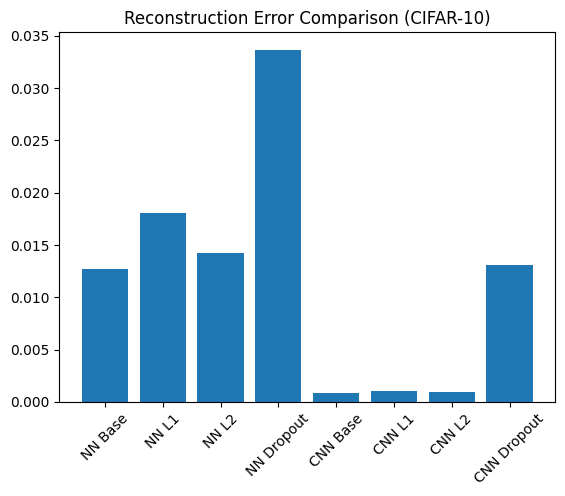

In [36]:
names = list(performance.keys())
values = list(performance.values())

plt.figure()
plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("Reconstruction Error Comparison (CIFAR-10)")
plt.show()

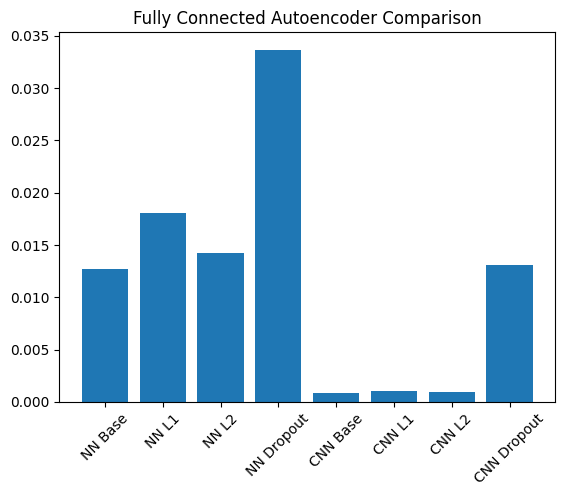

In [37]:
nn_names = [k for k in performance if "NN" in k]
nn_values = [performance[k] for k in nn_names]

plt.figure()
plt.bar(nn_names, nn_values)
plt.xticks(rotation=45)
plt.title("Fully Connected Autoencoder Comparison")
plt.show()

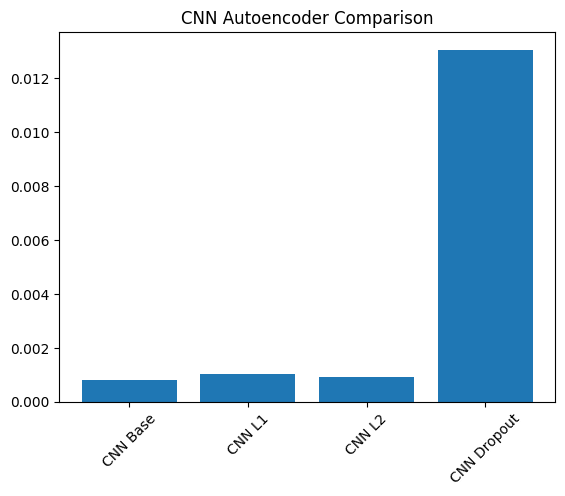

In [38]:
cnn_names = [k for k in performance if "CNN" in k]
cnn_values = [performance[k] for k in cnn_names]

plt.figure()
plt.bar(cnn_names, cnn_values)
plt.xticks(rotation=45)
plt.title("CNN Autoencoder Comparison")
plt.show()

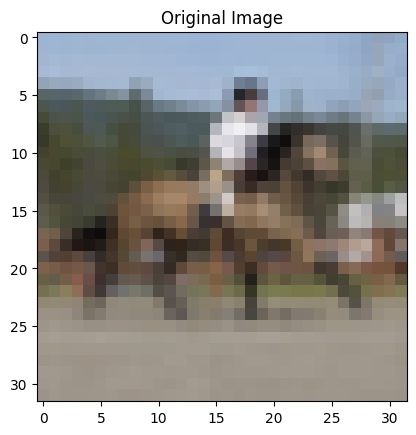

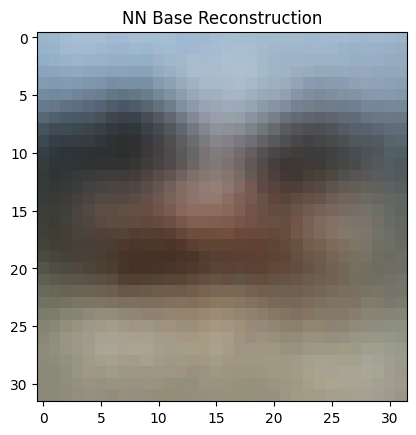

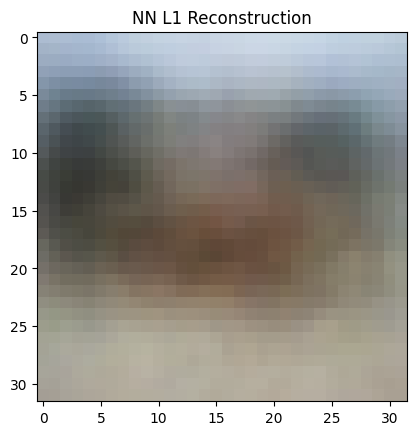

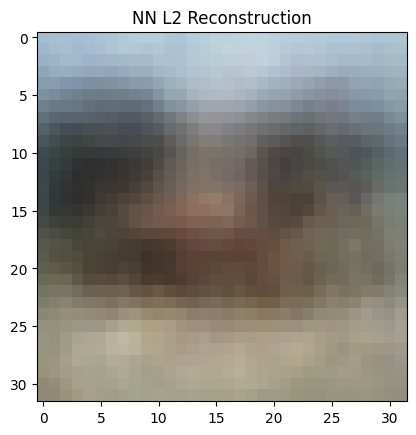

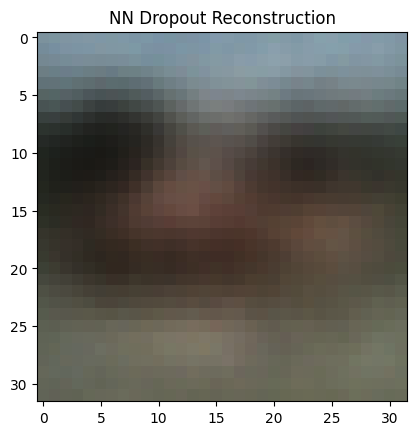

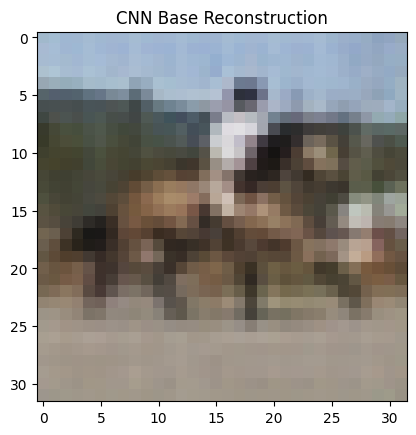

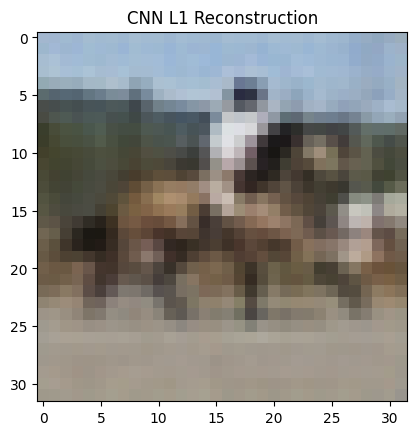

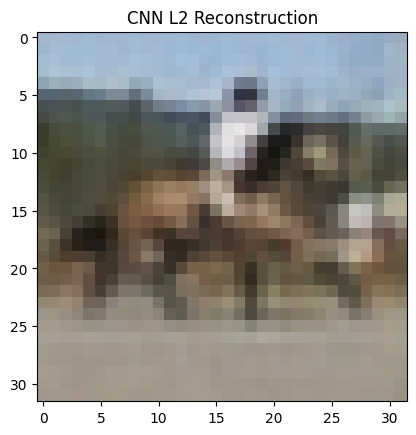

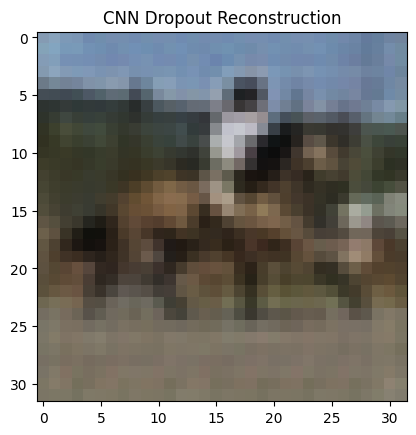

In [39]:
images, labels = next(iter(train_loader))
images = images.to(device)[:1]

plt.figure()
plt.imshow(images[0].cpu().permute(1,2,0))
plt.title("Original Image")
plt.show()

with torch.no_grad():
    for name, model in models.items():
        output = model(images)

        plt.figure()
        plt.imshow(output[0].cpu().permute(1,2,0))
        plt.title(name + " Reconstruction")
        plt.show()